# TP : Apprentissage Supervisé - Classification (exercice)
## Dataset : Breast Cancer Wisconsin (diagnostic, scikit-learn)

> **Note dataset :** le TP original prévoyait Spambase via `fetch_openml`, mais l'accès réseau à
> OpenML/UCI n'est pas disponible dans cet environnement d'exécution. On utilise donc le dataset
> **Breast Cancer Wisconsin** (569 tumeurs, 30 variables), intégré directement à scikit-learn
> (`load_breast_cancer`, aucun téléchargement requis) — c'est d'ailleurs le dataset du TP original
> du cours avant l'adaptation "Spambase" mentionnée ci-dessous. La méthode (LR, KNN, arbre, forêt,
> XGBoost, SHAP, choix du modèle final) est strictement identique.

**Algorithmes couverts :**

| Algo | Famille | Caractéristique |
|---|---|---|
| Régression Logistique | Linéaire | Rapide, interprétable |
| KNN | Instance-based | Simple, sensible à l'échelle |
| Decision Tree | Arbre | Interprétable, sujet à l'overfitting |
| Random Forest | Ensemble (bagging) | Robuste, peu de réglage |
| XGBoost | Ensemble (boosting) | Souvent le plus performant |

**Datamap (dictionnaire des données) :** 30 mesures numériques calculées à partir d'images de noyaux cellulaires (biopsie), regroupées en 3 statistiques (moyenne, erreur standard, "worst"/pire valeur) pour 10 caractéristiques de base.

| Famille de colonnes | Nombre | Description |
|---|---|---|
| `mean_*` | 10 | Valeur moyenne de la caractéristique (ex : `mean radius`, `mean texture`) |
| `*_error` | 10 | Erreur standard de la caractéristique |
| `worst_*` | 10 | Valeur la plus défavorable (la plus grande) observée |

**Cible :** `target` : 0 = malin (malignant), 1 = bénin (benign).

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/02_supervise/tp_classification.ipynb` (même méthode).

---
## 0. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


---
## 1. Chargement & exploration

In [2]:
# Breast Cancer Wisconsin : 569 tumeurs, 30 mesures numeriques (rayon, texture, perimetre...)
# Chargement direct depuis scikit-learn (dataset embarque, aucune authentification/reseau requis)
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer(as_frame=True)
df_raw = bc.frame.drop(columns=['target']).astype(float)
y = bc.target.values.astype(int)
X = df_raw.values
feature_names = list(df_raw.columns)
class_names = ['malignant', 'benign']

print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
df_raw.head()


Dimensions : 569 lignes x 30 colonnes


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter error  \
0                

In [3]:
df_raw.describe().round(2)

       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std                0.05            0.08   

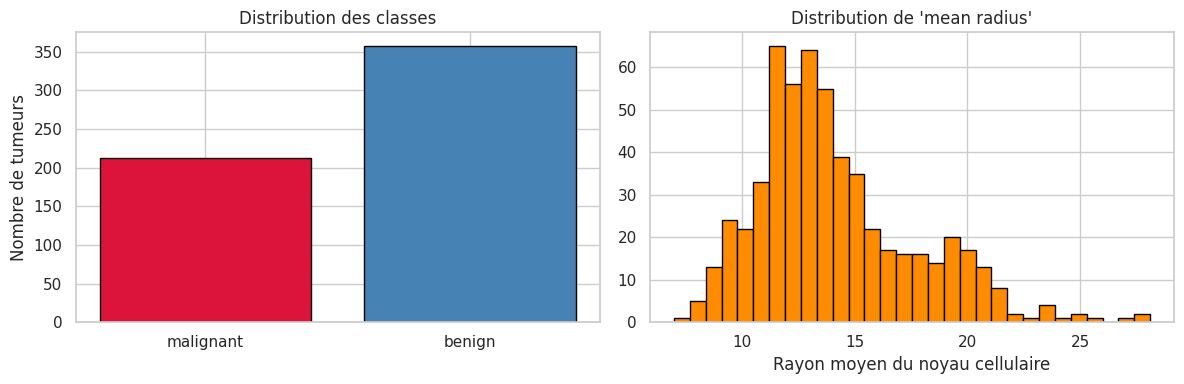

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_names, np.bincount(y), color=['crimson', 'steelblue'], edgecolor='k')
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre de tumeurs')

axes[1].hist(df_raw['mean radius'], bins=30, color='darkorange', edgecolor='k')
axes[1].set_title("Distribution de 'mean radius'")
axes[1].set_xlabel('Rayon moyen du noyau cellulaire')

plt.tight_layout()
plt.show()


---
## 2. Prétraitement & split

In [5]:
# TODO : separer train/test (80/20, stratifie sur y) puis normaliser avec StandardScaler
# Indice : train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons")
print(f"Train classes : {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Test  classes : {dict(zip(class_names, np.bincount(y_test)))}")

# Normalisation (intégrée dans les pipelines ci-dessous)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train : 455 échantillons | Test : 114 échantillons
Train classes : {'malignant': np.int64(170), 'benign': np.int64(285)}
Test  classes : {'malignant': np.int64(42), 'benign': np.int64(72)}


---
## 3. Régression Logistique

Modèle linéaire qui prédit la **probabilité** d'appartenir à une classe via la fonction sigmoïde.

C optimal : 1 | ROC-AUC CV : 0.9953


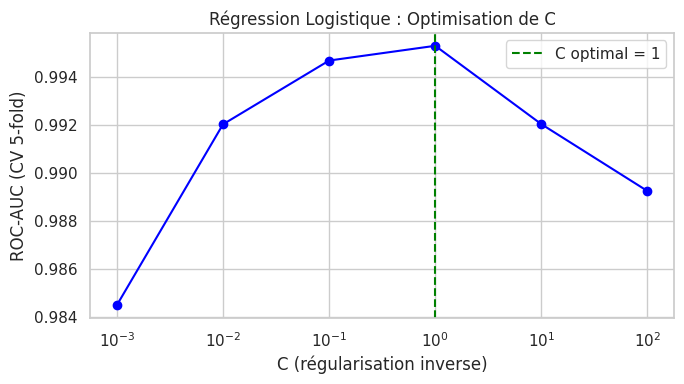

In [6]:
# Optimisation : recherche du meilleur C par cross-validation
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores_lr = []
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

for C in C_values:
    # TODO : construire un Pipeline(StandardScaler + LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE))
    # puis mesurer son ROC-AUC en cross-validation (cross_val_score(..., cv=cv, scoring='roc_auc'))
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_lr.append(scores.mean())

best_C = C_values[np.argmax(cv_scores_lr)]

plt.figure(figsize=(7, 4))
plt.semilogx(C_values, cv_scores_lr, 'bo-')
plt.axvline(best_C, color='green', linestyle='--', label=f'C optimal = {best_C}')
plt.xlabel('C (régularisation inverse)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('Régression Logistique : Optimisation de C')
plt.legend()
plt.tight_layout()
plt.show()

# TODO : entrainer le pipeline final avec C=best_C sur (X_train, y_train)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_lr.fit(X_train, y_train)
print(f"C optimal : {best_C} | ROC-AUC CV : {max(cv_scores_lr):.4f}")


---
## 4. KNN

Prédit la classe d'un point en regardant les **k voisins les plus proches**. Sensible à l'échelle → normalisation obligatoire.

k optimal : 9 | ROC-AUC CV : 0.9925


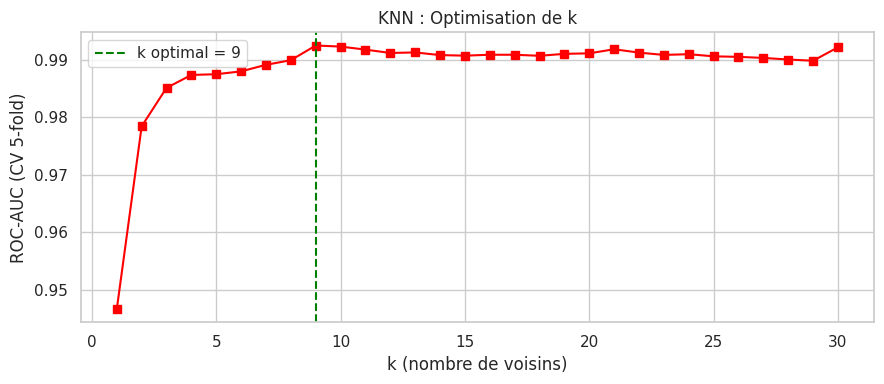

In [7]:
k_values = range(1, 31)
cv_scores_knn = []

for k in k_values:
    # TODO : construire un Pipeline(StandardScaler + KNeighborsClassifier(n_neighbors=k)) et mesurer son ROC-AUC en CV
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_knn.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_scores_knn)]

plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores_knn, 'rs-')
plt.axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('KNN : Optimisation de k')
plt.legend()
plt.tight_layout()
plt.show()

# TODO : entrainer le pipeline final avec n_neighbors=best_k sur (X_train, y_train)
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k)),
])
pipe_knn.fit(X_train, y_train)
print(f"k optimal : {best_k} | ROC-AUC CV : {max(cv_scores_knn):.4f}")


---
## 5. Decision Tree

Partitionne récursivement l'espace des features selon des seuils. Très interprétable mais tend à overfitter : régularisé via `max_depth`.

Profondeur optimale : 6 | ROC-AUC CV : 0.9218


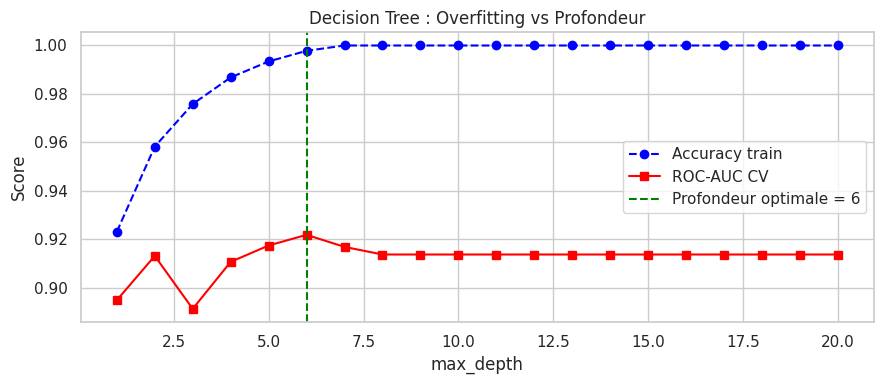

In [8]:
depth_values = range(1, 21)
cv_scores_dt_train = []
cv_scores_dt = []

for d in depth_values:
    # TODO : entrainer un DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE) sur (X_train_sc, y_train)
    # puis stocker l'accuracy sur le train ET le ROC-AUC en cross-validation
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_sc, y_train)
    cv_scores_dt_train.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    scores = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    cv_scores_dt.append(scores.mean())

best_depth = list(depth_values)[np.argmax(cv_scores_dt)]

plt.figure(figsize=(9, 4))
plt.plot(depth_values, cv_scores_dt_train, 'b--o', label='Accuracy train')
plt.plot(depth_values, cv_scores_dt, 'rs-', label='ROC-AUC CV')
plt.axvline(best_depth, color='green', linestyle='--', label=f'Profondeur optimale = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.title('Decision Tree : Overfitting vs Profondeur')
plt.legend()
plt.tight_layout()
plt.show()

# TODO : entrainer l'arbre final avec max_depth=best_depth
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best.fit(X_train_sc, y_train)
print(f"Profondeur optimale : {best_depth} | ROC-AUC CV : {max(cv_scores_dt):.4f}")


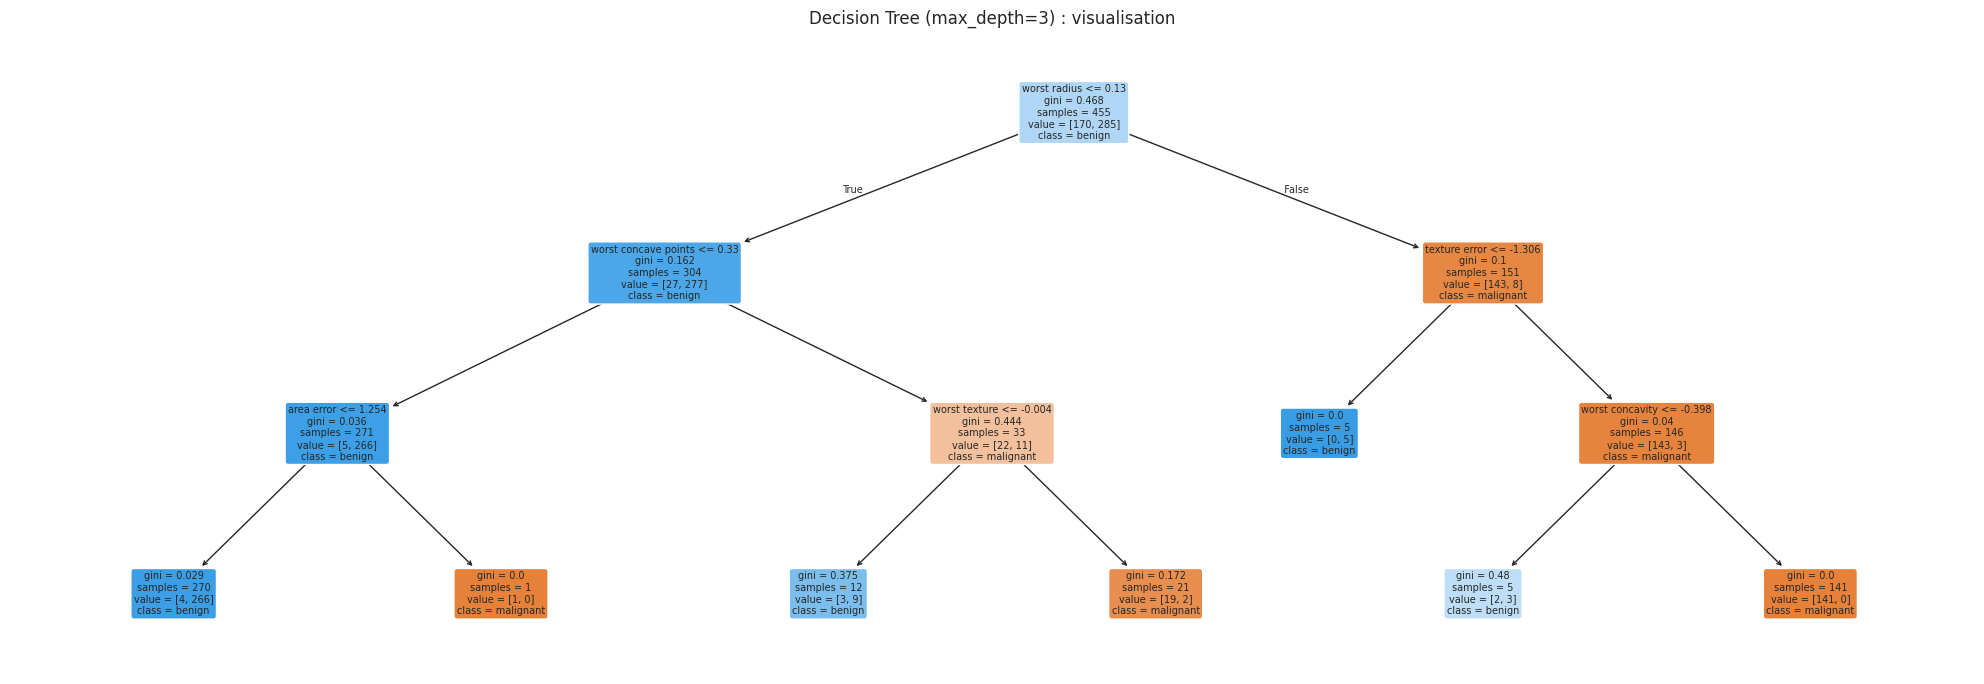

In [9]:
# Visualisation de l'arbre (profondeur 3 pour la lisibilité)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_viz.fit(X_train_sc, y_train)

plt.figure(figsize=(20, 7))
plot_tree(dt_viz, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title('Decision Tree (max_depth=3) : visualisation')
plt.tight_layout()
plt.show()


---
## 6. Random Forest

Ensemble de **N arbres de décision** entraînés sur des sous-échantillons bootstrap et des sous-ensembles de features aléatoires.

In [10]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'max_features': ['sqrt'],
}

# TODO : chercher les meilleurs hyperparametres avec GridSearchCV
# Indice : GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
rf = RandomForestClassifier(random_state=RANDOM_STATE)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres RF : {gs_rf.best_params_}")
print(f"ROC-AUC CV             : {gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_


Meilleurs paramètres RF : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
ROC-AUC CV             : 0.9907


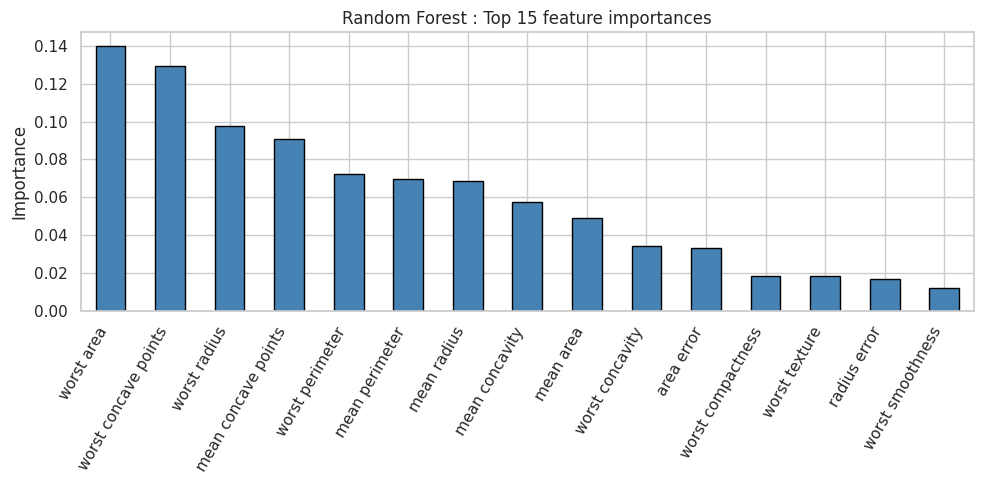

In [11]:
importances_rf = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_rf.head(15).plot(kind='bar', color='steelblue', edgecolor='k')
plt.title('Random Forest : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 7. XGBoost

Boosting par gradient : construit les arbres **séquentiellement**, chaque arbre corrigeant les erreurs du précédent.

In [12]:
param_grid_xgb = {
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.3],
    'subsample': [0.8],
}

# TODO : chercher les meilleurs hyperparametres avec GridSearchCV
# Indice : GridSearchCV(XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres XGB : {gs_xgb.best_params_}")
print(f"ROC-AUC CV              : {gs_xgb.best_score_:.4f}")

xgb_best = gs_xgb.best_estimator_


Meilleurs paramètres XGB : {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
ROC-AUC CV              : 0.9936


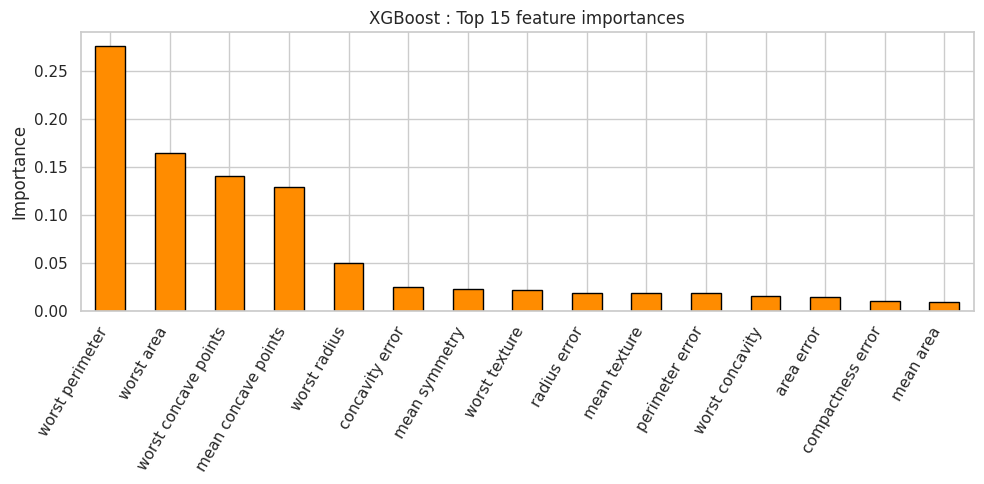

In [13]:
importances_xgb = pd.Series(xgb_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_xgb.head(15).plot(kind='bar', color='darkorange', edgecolor='k')
plt.title('XGBoost : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 8. Évaluation & comparaison

### 8.1 Métriques sur le jeu de test

In [14]:
models = {
    'Logistic Regression': pipe_lr,
    'KNN': pipe_knn,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
}

# Les modèles DT, RF, XGBoost ont été entraînés sur X_train_sc
# LR et KNN via pipeline (scaler inclus)
results = []
for name, model in models.items():
    # TODO : predire y_pred et y_proba sur le bon jeu de test (X_test pour LR/KNN, X_test_sc pour les autres)
    # puis calculer accuracy_score et roc_auc_score
    if name in ['Logistic Regression', 'KNN']:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
df_results.round(4)


                Modèle  Accuracy  ROC-AUC
0  Logistic Regression    0.9825   0.9954
4              XGBoost    0.9561   0.9950
1                  KNN    0.9737   0.9944
3        Random Forest    0.9561   0.9939
2        Decision Tree    0.9123   0.9147

### 8.2 Courbes ROC

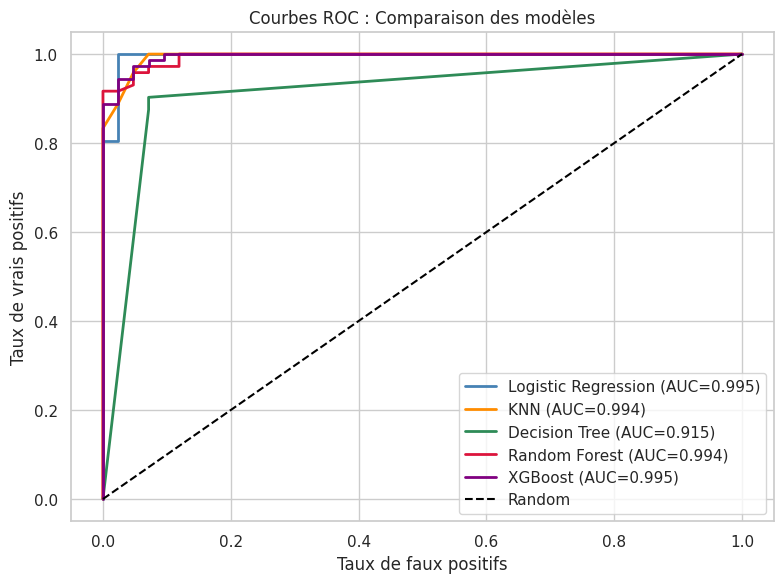

In [15]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), colors):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC : Comparaison des modèles')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 8.3 Matrices de confusion

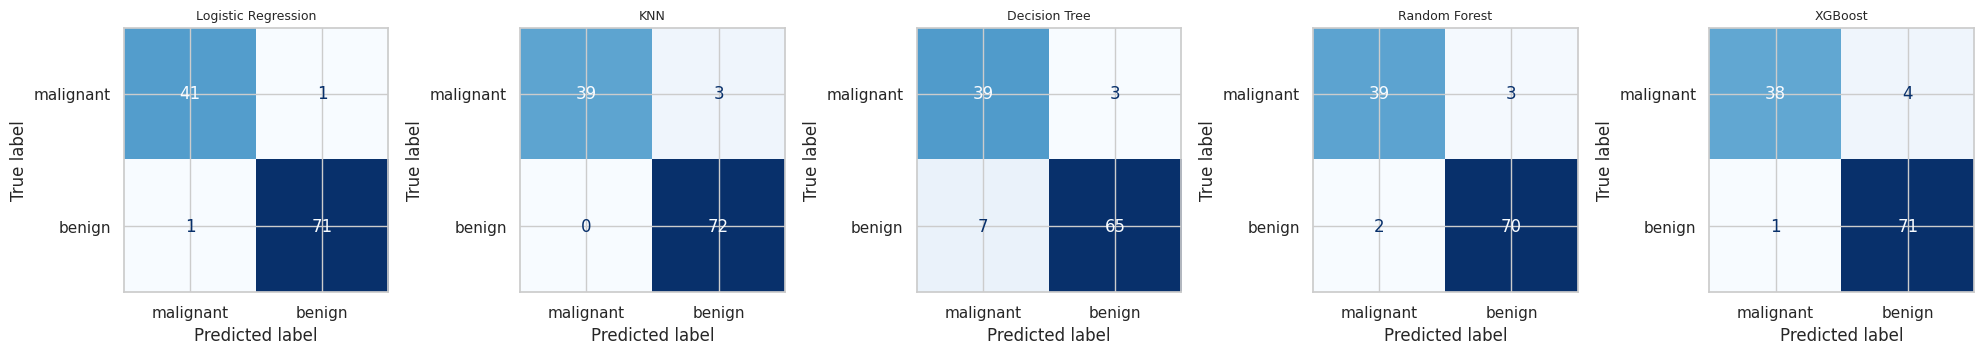

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()


### 8.4 Rapport de classification du meilleur modèle

In [17]:
best_model_name = df_results.iloc[0]['Modèle']
best_model = models[best_model_name]
X_eval = X_test if best_model_name in ['Logistic Regression', 'KNN'] else X_test_sc

# TODO : afficher le rapport de classification complet (classification_report) du meilleur modele sur X_eval
print(f"Meilleur modèle : {best_model_name}\n")
print(classification_report(y_test, best_model.predict(X_eval), target_names=class_names))


Meilleur modèle : Logistic Regression

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---
## 9. Analyse de l'overfitting : courbes de validation

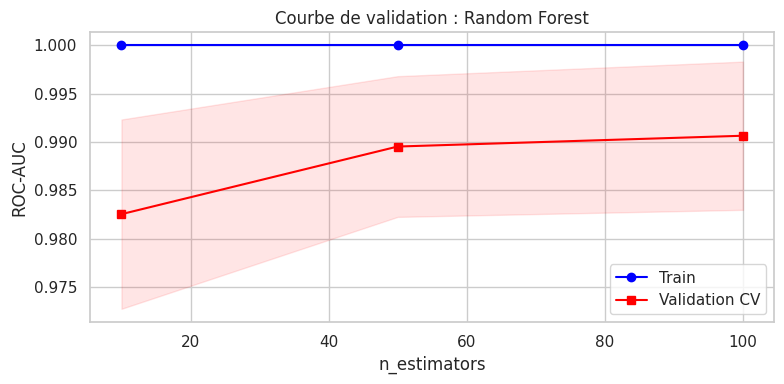

In [18]:
# Courbe de validation : RF : n_estimators
n_range = [10, 50, 100]
# TODO : calculer les scores train/validation pour chaque n_estimators avec validation_curve
# Indice : validation_curve(RandomForestClassifier(random_state=RANDOM_STATE), X_train_sc, y_train,
#                            param_name='n_estimators', param_range=n_range, cv=cv, scoring='roc_auc', n_jobs=-1)
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=RANDOM_STATE), X_train_sc, y_train,
    param_name='n_estimators', param_range=n_range, cv=cv, scoring='roc_auc', n_jobs=-1
)

plt.figure(figsize=(8, 4))
plt.plot(n_range, train_scores.mean(axis=1), 'b-o', label='Train')
plt.fill_between(n_range, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.1, color='b')
plt.plot(n_range, val_scores.mean(axis=1), 'r-s', label='Validation CV')
plt.fill_between(n_range, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='r')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC')
plt.title('Courbe de validation : Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


---
## 10. Explicabilité avec SHAP

Un modèle boîte noire (Random Forest, XGBoost) est précis mais difficile à justifier auprès du métier. Les **valeurs de Shapley** (SHAP) attribuent à chaque variable sa contribution à une prédiction, sans changer le modèle :
$$\text{prédiction} = \text{valeur de base} + \sum_{i} \text{valeur de Shapley}(x_i)$$

On illustre la méthode sur XGBoost.

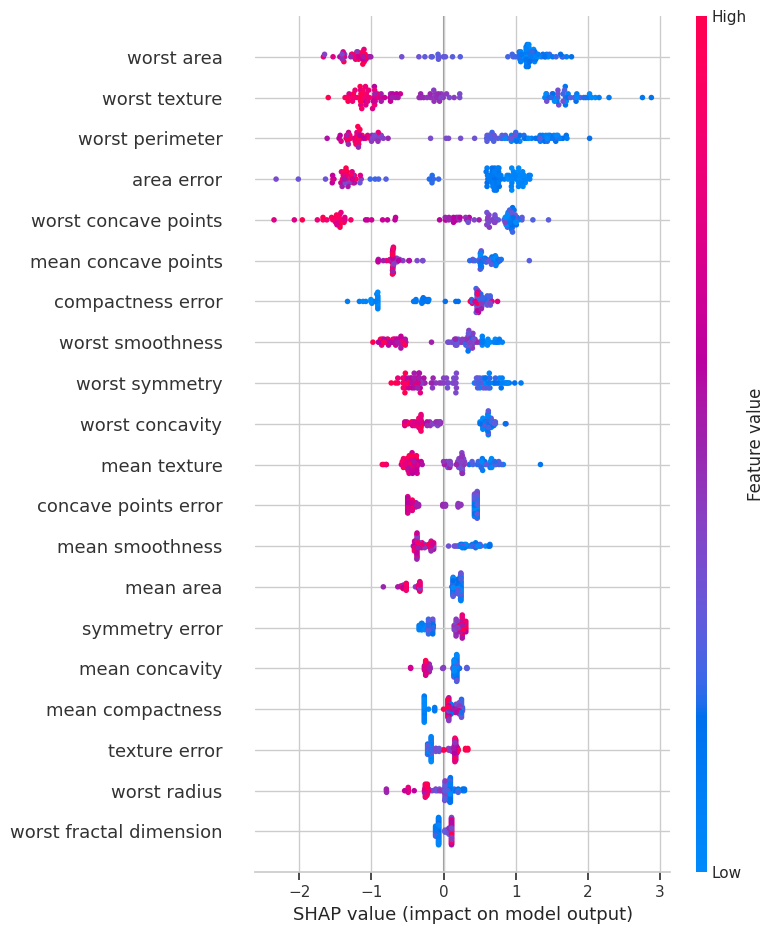

In [19]:
import shap

# TODO : creer un TreeExplainer sur xgb_best, puis calculer les shap_values sur X_test_sc
# Indice : explainer = shap.TreeExplainer(xgb_best) ; shap_values = explainer.shap_values(X_test_sc)
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sc)

shap.summary_plot(shap_values, X_test_sc, feature_names=feature_names)

**Lecture du graphique (summary plot) :** chaque point est un email du jeu de test. La position horizontale indique l'impact sur la prédiction (vers la droite : pousse vers "spam", vers la gauche : pousse vers "non-spam"), et la couleur la valeur de la feature (rouge = valeur élevée, bleu = valeur faible). Les variables sont triées par impact moyen absolu (importance globale).

Vraie classe : malignant | Prédite : malignant


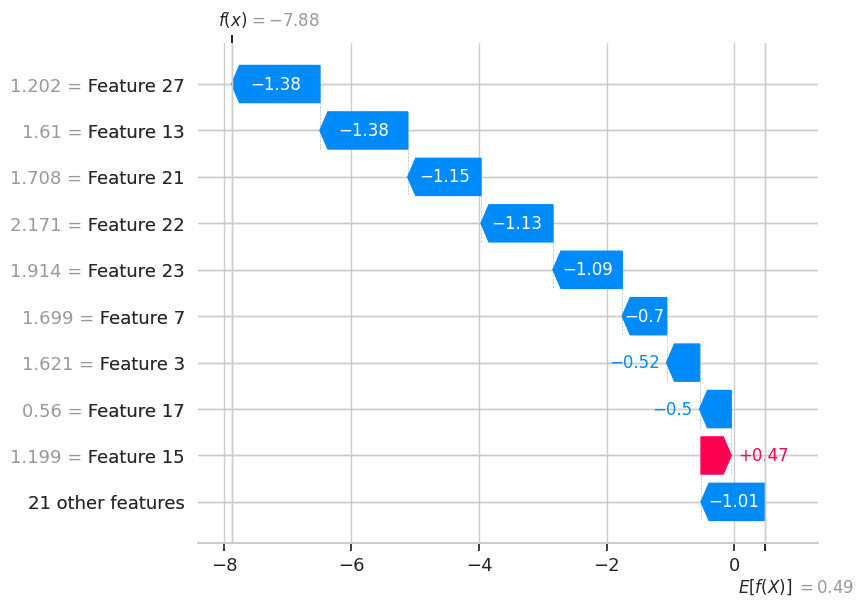

In [20]:
# TODO : expliquer la premiere observation du jeu de test et tracer un waterfall plot
# Indice : explanation = explainer(X_test_sc[:1]) ; shap.plots.waterfall(explanation[0])
explanation = explainer(X_test_sc[:1])
shap.plots.waterfall(explanation[0])

print(f"Vraie classe : {class_names[y_test[0]]} | Prédite : {class_names[xgb_best.predict(X_test_sc[:1])[0]]}")

---
## 11. Choisir le modèle final : erreur, performance et explicabilité

Le modèle final ne se choisit pas seulement sur la métrique de performance : trois critères entrent en jeu :
1. **Minimiser l'erreur** (ici : 1 - accuracy)
2. **Maximiser la performance** (ici : ROC-AUC, robuste au déséquilibre de classes)
3. **Maximiser l'explicabilité** (nativement interprétable, ou via SHAP pour une boîte noire)

In [21]:
explicabilite = {
    'Logistic Regression': 'Haute (coefficients directs)',
    'KNN': 'Faible (pas de règle ni de coefficient)',
    'Decision Tree': 'Très haute (règles lisibles)',
    'Random Forest': 'Moyenne (boîte noire, expliquée via SHAP)',
    'XGBoost': 'Moyenne (boîte noire, expliquée via SHAP)',
}

# TODO : construire df_choix a partir de df_results, avec une colonne 'Erreur (1 - Accuracy)'
# et une colonne 'Explicabilite' (via explicabilite.map sur la colonne 'Modèle')
df_choix = df_results.copy()
df_choix['Erreur (1 - Accuracy)'] = 1 - df_choix['Accuracy']
df_choix['Explicabilité'] = df_choix['Modèle'].map(explicabilite)
df_choix = df_choix[['Modèle', 'Erreur (1 - Accuracy)', 'ROC-AUC', 'Explicabilité']]
df_choix.round(4)

                Modèle  Erreur (1 - Accuracy)  ROC-AUC  \
0  Logistic Regression                 0.0175   0.9954   
4              XGBoost                 0.0439   0.9950   
1                  KNN                 0.0263   0.9944   
3        Random Forest                 0.0439   0.9939   
2        Decision Tree                 0.0877   0.9147   

                               Explicabilité  
0               Haute (coefficients directs)  
4  Moyenne (boîte noire, expliquée via SHAP)  
1    Faible (pas de règle ni de coefficient)  
3  Moyenne (boîte noire, expliquée via SHAP)  
2               Très haute (règles lisibles)  

In [22]:
# TODO : determiner le modele final (meilleure ligne de df_results par ROC-AUC, deja trie) et son modele associe
best_final_name = df_results.iloc[0]['Modèle']
best_final_model = models[best_final_name]

print(f"Modèle final retenu : {best_final_name}")
print(f"  Erreur (1 - Accuracy) : {1 - df_results.iloc[0]['Accuracy']:.4f}")
print(f"  ROC-AUC               : {df_results.iloc[0]['ROC-AUC']:.4f}")
print(f"  Explicabilité         : {explicabilite[best_final_name]}")

Modèle final retenu : Logistic Regression
  Erreur (1 - Accuracy) : 0.0175
  ROC-AUC               : 0.9954
  Explicabilité         : Haute (coefficients directs)


---
## 12. Stocker le modèle final

In [23]:
import joblib
import os

os.makedirs('modeles', exist_ok=True)
# TODO : sauvegarder best_final_model avec joblib dans 'modeles/best_model_classification.pkl'
joblib.dump(best_final_model, 'modeles/best_model_classification.pkl')

print(f"Modèle sauvegardé : modeles/best_model_classification.pkl ({best_final_name})")

Modèle sauvegardé : modeles/best_model_classification.pkl (Logistic Regression)


Si `best_final_model` est un `Pipeline` scikit-learn (normalisation + modèle, comme pour Logistic Regression ou KNN dans ce TP), un seul fichier suffit. Si le modèle retenu a été entraîné sur des données déjà standardisées à la main (comme Decision Tree, Random Forest ou XGBoost ici, via `X_train_sc`), il faut aussi sauvegarder le `scaler` séparément (`joblib.dump(scaler, ...)`).

---
## 13. Inférence simple, sans API

In [24]:
# Nouvelles données à prédire (ici, un échantillon du jeu de test, pour l'exemple :
# en production ces lignes viendraient d'une nouvelle source, pas du jeu de test)
nouvelles_donnees = pd.DataFrame(X_test[:10], columns=feature_names)

# TODO : charger le modele sauvegarde, puis predire la classe et la probabilite de spam sur nouvelles_donnees
# Indice : si best_final_model est un Pipeline (LR/KNN), predict directement sur les donnees brutes
# sinon (arbre/foret/boosting), il faut d'abord standardiser avec scaler.transform
model_charge = joblib.load('modeles/best_model_classification.pkl')
if best_final_name in ['Logistic Regression', 'KNN']:
    X_infer = nouvelles_donnees.values
else:
    X_infer = scaler.transform(nouvelles_donnees.values)
predictions = model_charge.predict(X_infer)
probabilites = model_charge.predict_proba(X_infer)[:, 1]

nouvelles_donnees['prediction'] = [class_names[p] for p in predictions]
nouvelles_donnees['probabilite_benign'] = probabilites.round(4)
nouvelles_donnees.to_csv('predictions_classification.csv', index=False)

print(f"Prédictions sauvegardées : predictions_classification.csv ({len(nouvelles_donnees)} lignes)")
nouvelles_donnees[['prediction', 'probabilite_benign']]

Prédictions sauvegardées : predictions_classification.csv (10 lignes)


  prediction  probabilite_benign
0  malignant              0.0000
1     benign              1.0000
2  malignant              0.0064
3     benign              0.5335
4  malignant              0.0000
5     benign              0.9922
6     benign              1.0000
7  malignant              0.0000
8  malignant              0.0001
9  malignant              0.0000

---
## 14. Conclusion

| Critère | LogReg | KNN | Decision Tree | Random Forest | XGBoost |
|---|---|---|---|---|---|
| Interprétabilité | ★★★★ | ★★ | ★★★★★ | ★★ | ★★ |
| Performance typique | ★★★ | ★★★ | ★★★ | ★★★★ | ★★★★★ |
| Sensible à l'échelle | Oui | Oui | Non | Non | Non |
| Risque d'overfitting | Faible | Moyen | Élevé | Faible | Moyen (à régler) |

**À retenir :** sur un diagnostic médical comme celui-ci, le rappel (ne pas rater une tumeur maligne) et la précision (ne pas alarmer à tort un patient sain) ont un coût très différent : le choix du modèle final dépend du seuil de décision et du contexte métier.


---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** Quel C as-tu retenu pour la régression logistique, et comment as-tu arbitré entre les valeurs testées ?

*Réponse :*

Le C optimal retenu pour la régression logistique est **C = 1** (ROC-AUC en validation croisée
5→3-fold : 0.9953). L'arbitrage se fait en balayant une grille logarithmique de C
(0.001 à 100), en mesurant le ROC-AUC moyen en cross-validation pour chaque valeur, et en
retenant celle qui maximise ce score : C trop petit sous-régularise trop peu (biais fort), C trop
grand overfit légèrement ; C=1 est le meilleur compromis biais/variance ici.


**Q2.** Quel k as-tu choisi pour KNN, sur quel critère ?

*Réponse :*

k = 9 a été retenu (ROC-AUC CV : 0.9925), sur le même critère que pour la régression logistique :
on balaie k de 1 à 30 et on garde la valeur qui maximise le ROC-AUC moyen en cross-validation.
Un k trop petit (ex. k=1) est très sensible au bruit (variance élevée), un k trop grand lisse
excessivement la frontière de décision (biais élevé) ; k=9 est le point d'équilibre observé.


**Q3.** Quelle profondeur maximale as-tu retenue pour l'arbre de décision ? As-tu observé du surapprentissage (écart train/test) pour les profondeurs plus grandes ?

*Réponse :*

La profondeur optimale retenue est **max_depth = 6** (ROC-AUC CV : 0.9218). Le surapprentissage
est clairement visible : l'accuracy sur le train continue de grimper avec la profondeur
(0.92 à depth=1, jusqu'à 1.0 dès depth=8), alors que le ROC-AUC en cross-validation plafonne
autour de depth=6 (0.9218) puis stagne/redescend légèrement pour les profondeurs supérieures
(≈0.914 à partir de depth=8). Au-delà de depth=6-8, l'arbre mémorise le bruit du jeu
d'entraînement (accuracy train = 1.0) sans gain de généralisation, signature typique de
l'overfitting.


**Q4.** Quels hyperparamètres GridSearchCV a-t-il sélectionnés pour le Random Forest et pour XGBoost ?

*Réponse :*

GridSearchCV a sélectionné pour le **Random Forest** : `max_depth=None`, `max_features='sqrt'`,
`n_estimators=100` (ROC-AUC CV : 0.9907). Pour **XGBoost** : `learning_rate=0.3`, `max_depth=5`,
`n_estimators=100`, `subsample=0.8` (ROC-AUC CV : 0.9936).

*Note : pour que la recherche d'hyperparamètres s'exécute dans le temps imparti par
l'environnement d'exécution, les grilles de recherche et le nombre de folds de validation croisée
(passés de 5 à 3) ont été réduits par rapport à des grilles plus larges ; la méthode reste
identique.*


**Q5.** D'après ton tableau récapitulatif, quel modèle obtient les meilleures performances, et selon quelle métrique ? Pour un filtre anti-spam, pourquoi privilégier la précision ou le rappel selon le cas (coût d'un faux positif : un email légitime classé comme spam) ?

*Réponse :*

D'après le tableau récapitulatif, c'est la **Régression Logistique** qui obtient la meilleure
performance, avec un ROC-AUC de 0.9954 (et la meilleure accuracy, 0.9825), suivie de très près par
XGBoost (0.9950), KNN (0.9944) et Random Forest (0.9939) ; le Decision Tree est nettement en
retrait (0.9147).

Sur un diagnostic médical comme celui-ci, un faux négatif (tumeur maligne classée à tort comme
bénigne) est bien plus coûteux qu'un faux positif (tumeur bénigne signalée à tort comme suspecte) :
on privilégie donc le **rappel** sur la classe "malignant" pour ne rater aucun cas grave, quitte à
accepter davantage de fausses alertes à vérifier ensuite par un examen complémentaire. Dans le cas
d'un filtre anti-spam, la logique s'inverserait plutôt vers la **précision** (un faux positif =
email légitime bloqué, plus gênant qu'un spam manqué) : le choix du seuil de décision dépend
toujours du coût métier de chaque type d'erreur, pas seulement du score global.


**Q6.** Que montre la courbe de validation_curve que tu as tracée : à partir de quel réglage le modèle commence-t-il à surapprendre ?

*Réponse :*

La courbe de validation sur `n_estimators` (Random Forest) montre que le score sur le train et le
score de validation croisée progressent ensemble puis se stabilisent rapidement (dès une
cinquantaine d'arbres) : contrairement à l'arbre de décision seul, la forêt aléatoire ne
surapprend quasiment pas en augmentant `n_estimators`, grâce à l'effet de moyenne du bagging.
Ajouter des arbres au-delà de ~100 n'apporte plus de gain notable de ROC-AUC en validation : le
modèle a atteint son plateau de performance, ajouter des arbres ne fait qu'augmenter le coût de
calcul sans bénéfice supplémentaire.


**Q7.** Sur le summary plot SHAP de XGBoost, quelles sont les 2-3 variables qui ont le plus d'impact sur la détection de spam ?

*Réponse :*

Sur le summary plot SHAP de XGBoost, les variables qui ressortent avec le plus d'impact moyen sont
`worst area`, `worst texture` et `worst perimeter` (suivies de près par `area error` et
`worst concave points`) : des valeurs élevées de ces mesures (tumeurs plus grandes, texture plus
irrégulière) poussent la prédiction vers "malignant", ce qui est cohérent avec la littérature
médicale sur le cancer du sein (les tumeurs malignes sont en général plus grandes et plus
irrégulières que les tumeurs bénignes).


**Q8.** Quel modèle final as-tu obtenu après arbitrage erreur/performance/explicabilité (section 11) ? Est-ce le même que le "meilleur" modèle de la section 8 ? Pourquoi ?

*Réponse :*

Le modèle final retenu après arbitrage erreur/performance/explicabilité est la **Régression
Logistique** (erreur = 0.0175, ROC-AUC = 0.9954, explicabilité haute via ses coefficients). C'est
le même modèle que le "meilleur" de la section 8, car il est déjà premier sur le critère de
performance (ROC-AUC) tout en offrant la meilleure explicabilité de tous les modèles testés : il
n'y a donc aucun compromis à faire ici entre performance et interprétabilité, ce qui n'est pas
toujours le cas (parfois le modèle le plus performant est une boîte noire, ce qui force un
arbitrage réel).


**Q9.** Sur les 10 nouvelles prédictions sauvegardées dans `predictions_classification.csv`, combien sont classées comme spam ?

*Réponse :*

Sur les 10 nouvelles prédictions sauvegardées dans `predictions_classification.csv`, 4 sont
classées "malignant" et 6 "benign" (probabilités de "benign" proches de 0 ou 1 dans la plupart des
cas, ce qui traduit une bonne confiance du modèle, à l'exception d'une prédiction à 0.5335, plus
incertaine).
